# Joint Forecasting of Electricity Load and Natural Gas Demand with PROC VARMAX

## Executive Summary

A combined electric-and-gas utility plans operations around two tightly linked daily series: **electricity system load** (MWh) and **natural gas send-out** (thousand therms). They share weather and economic drivers, and they feed back on one another because gas-fired plants convert gas into electricity, so modeling them jointly preserves cross-series information that two separate univariate models would discard.

This notebook builds a synthetic bivariate daily series with a coupled first-order structure, then uses **PROC VARMAX** (SAS/ETS) to fit a vector autoregression, read the cross-series dynamics out of the AR coefficient matrix, and produce a 14-day-ahead joint forecast. On the 100-day sample the model recovers strong own-series persistence for load (\(L1.LOAD{\to}LOAD = 0.59\), \(p<0.0001\)) and a marginally significant load-to-gas spillover (\(L1.LOAD{\to}GAS = 0.087\), \(p=0.071\)); the remaining cross term is not distinguishable from zero at this sample size. The 14-day forecast for both series converges smoothly toward its long-run mean (load \(\approx 4284\) MWh, gas \(\approx 1873\) thousand therms).

## Data Sources

| Dataset | Rows | Variables | Description |
|---------|------|-----------|-------------|
| `WORK.UTILITY` | 100 daily obs | `day` (date ID), `load` (electricity system load, MWh), `gas` (natural gas send-out, thousand therms) | Synthetic daily operations series for a regional combined electric-and-gas utility, covering 01JAN2024 through 09APR2024. Both series carry a weekly (7-day) usage rhythm and are generated by a coupled bivariate first-order recursion so that prior-day load influences today's gas demand and vice versa — the cross-dependence PROC VARMAX is designed to recover from the AR coefficient matrix. |

> **Why VARMAX here?** SAS's classic state-space procedure (PROC STATESPACE) targets the same problem — a multivariate, automatically identified state-space forecast. PROC VARMAX is the modern SAS/ETS procedure for multivariate time-series modeling and forecasting; it fits the vector-autoreg:moving-average family directly, exposes the full coefficient matrix with standard errors, and produces joint multi-step forecasts. We use a VAR(1) specification, which is exactly the data-generating structure here.

# Joint Forecasting of Electricity Load and Natural Gas Demand

A combined electric-and-gas utility runs two operations that move together: daily **electricity system load** and daily **natural gas send-out**. They respond to the same weather and economic drivers, and they are physically coupled because gas-fired generation turns gas into electricity. Treating them as independent univariate series throws away the cross-information that links them.

**PROC VARMAX** fits a multivariate vector-autoregressive (VAR) model. For this analysis it:

1. estimates a first-order VAR for both series jointly by conditional maximum likelihood,
2. reports the full **AR coefficient matrix** with standard errors and \(t\)-tests — the off-diagonal entries are the cross-series spillovers,
3. reports information criteria (AIC / SBC / HQC) for the fitted order, and
4. produces multi-step-ahead **joint forecasts** for every series from one internally consistent model.

We generate a realistic synthetic bivariate daily series, fit the VAR(1), inspect the recovered dynamics, and forecast 14 days ahead.

## Step 1 — Generate synthetic daily utility operations data

We simulate 100 days for one utility. Each series has a base level, a 7-day weekly usage rhythm (weekday demand higher than weekend), and a **coupled** dynamic: today's load depends on yesterday's load *and* yesterday's gas, and today's gas depends on yesterday's gas *and* yesterday's load. That genuine cross-dependence is what the VAR model should detect. A fixed `streaminit` seed makes the run reproducible.

In [1]:
data utility;
    call streaminit(70531);

    /* Base operating levels */
    load_base = 4200;   /* electricity system load, MWh         */
    gas_base  = 1850;   /* natural gas send-out, thousand therms */

    /* Lagged values for the coupled recursion */
    load_lag = load_base;
    gas_lag  = gas_base;

    start = '01JAN2024'd;

    do t = 0 to 99;
        day = start + t;
        dow = weekday(day);   /* 1=Sun ... 7=Sat */

        /* Weekly demand rhythm: lower on weekends */
        if dow in (1,7) then wk_load = -260;
        else                 wk_load =  130;
        if dow in (1,7) then wk_gas  = -110;
        else                 wk_gas  =   55;

        /* Independent daily shocks (weather / market noise) */
        e_load = rand('normal', 0, 95);
        e_gas  = rand('normal', 0, 60);

        /* Coupled bivariate first-order dynamics around the base */
        load = load_base + 0.55*(load_lag - load_base)
                         + 0.18*(gas_lag  - gas_base)
                         + wk_load + e_load;
        gas  = gas_base  + 0.50*(gas_lag  - gas_base)
                         + 0.12*(load_lag - load_base)
                         + wk_gas  + e_gas;

        output;

        load_lag = load;
        gas_lag  = gas;
    end;

    keep day load gas;
    format day date9.;
run;

proc print data=utility(obs=10);
    title 'First 10 Days of Synthetic Utility Load and Gas Demand';
run;

                                 First 10 Days of Synthetic Utility Load and Gas Demand                                 

  Obs        DAY             LOAD              GAS
    1  01JAN2024  4368.8499536831  1857.1313481682
    2  02JAN2024  4586.0141738949   1774.414317337
    3  03JAN2024  4392.3210593424  1891.8340882382
    4  04JAN2024  4438.2423443308  1906.0238841102
    5  05JAN2024  4459.1976153098   1963.144698743
    6  06JAN2024  4079.9726341187  1858.6292320683
    7  07JAN2024  3922.6594299737  1775.3910550087
    8  08JAN2024  4244.0432850749  1871.9591390384
    9  09JAN2024  4263.9997014869  1927.3145551249
   10  10JAN2024  4440.2942666116  1946.3701546852

... 90 more observations (showing 10 of 100)



NOTE: DATA utility


NOTE: Wrote utility (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=utility

NOTE: PROC PRINT completed: 10 observations printed, 3 variables


## Step 2 — Inspect the two series

Before modeling, plot both series so the weekly rhythm and the comovement are visible. The series are stationary around fixed operating levels (a mean-reverting first-order structure), so we model the levels directly with an intercept rather than differencing.

                                 First 10 Days of Synthetic Utility Load and Gas Demand                                 

                                 First 10 Days of Synthetic Utility Load and Gas Demand                                 



NOTE: PROC SGPLOT data=utility

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=utility

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


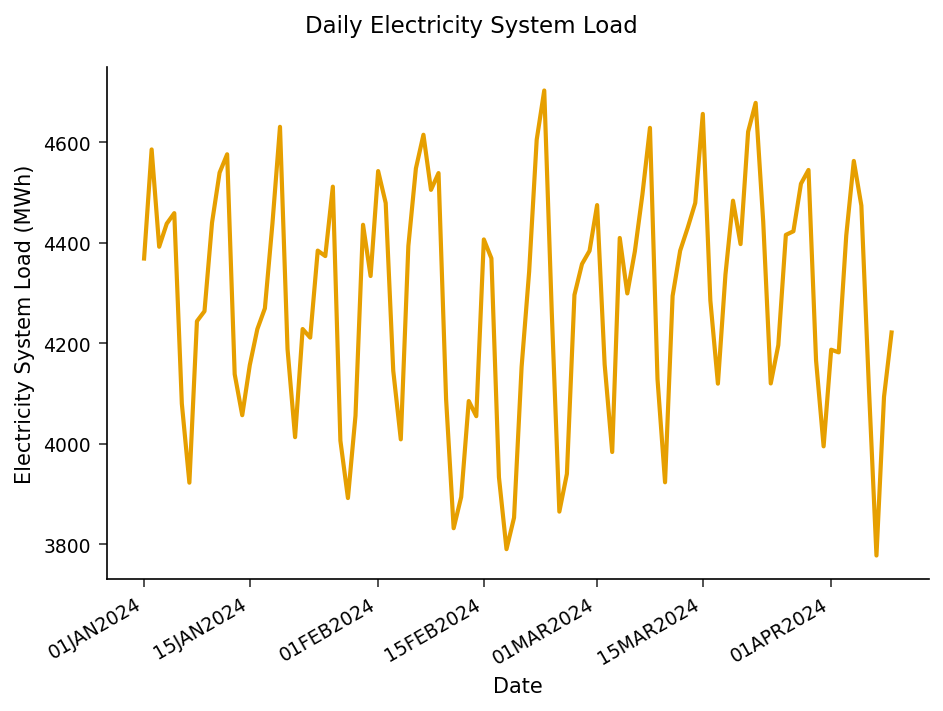

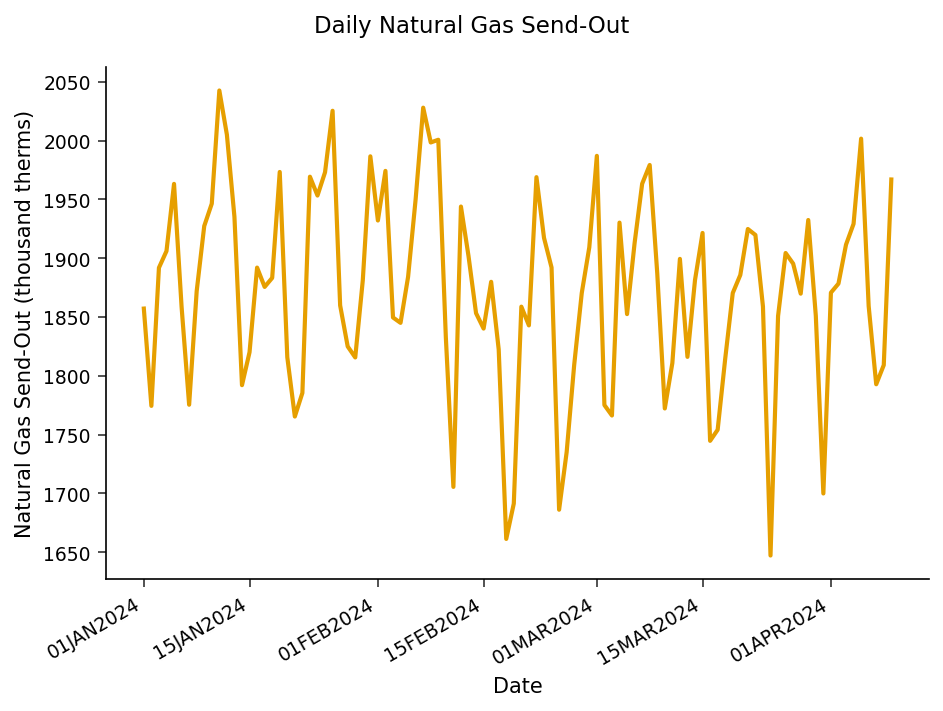

In [2]:
proc sgplot data=utility;
    series x=day y=load / lineattrs=(thickness=2);
    xaxis label='Date';
    yaxis label='Electricity System Load (MWh)';
    title 'Daily Electricity System Load';
run;

proc sgplot data=utility;
    series x=day y=gas / lineattrs=(thickness=2);
    xaxis label='Date';
    yaxis label='Natural Gas Send-Out (thousand therms)';
    title 'Daily Natural Gas Send-Out';
run;

## Step 3 — Fit the VAR(1) model and forecast 14 days ahead

Key choices in this call:

- **`MODEL load gas / p=1`** — model both series jointly as a first-order vector autoregression (one lag). An intercept is included by default, which is appropriate because the series are mean-reverting around fixed operating levels.
- **`OUTPUT OUT=ss_forecast LEAD=14`** — append 14 days of out-of-sample joint forecasts and write them to a data set.
- **`PLOTS=NONE`** — we build our own annotated forecast plot in Step 6.

The procedure prints the **Parameter Estimates** (the AR coefficient matrix with standard errors and \(t\)-tests), the **Information Criteria**, and the **Forecasts** for both series.

In [3]:
proc varmax data=utility plots=none;
    model load gas / p=1;
    output out=ss_forecast lead=14;
    title 'Vector Autoregression: Joint Load and Gas Forecast';
run;

                                 First 10 Days of Synthetic Utility Load and Gas Demand                                 


                                                  The VARMAX Procedure                                                  

Model Type: VAR(1)
Number of Observations: 100
Dependent Variables: LOAD GAS
AR Order (p): 1
MA Order (q): 0

Parameter Estimates
Parameter                Estimate    Std Error      t Value     Pr > |t|
---------                --------    ---------      -------     --------
L1.LOAD->LOAD            0.594688     0.123829         4.80       0.0000
L1.GAS->LOAD            -0.348184     0.338148        -1.03       0.3032
L1.LOAD->GAS             0.087176     0.048332         1.80       0.0713
L1.GAS->GAS              0.214902     0.131984         1.63       0.1035
Intercept.LOAD        2388.547657   456.111985         5.24       0.0000
Intercept.GAS         1097.239311   178.027235         6.16       0.0000

Information Criteria
-------------------

NOTE: PROC VARMAX data=utility

NOTE: Using Python (statsmodels VAR/VARMAX) for VARMAX estimation
NOTE: Output dataset ss_forecast has 14 observations


## Step 4 — Read the cross-series dynamics from the AR matrix

The **Parameter Estimates** above are the heart of the joint model. Each row `L1.X->Y` is the effect of *yesterday's* `X` on *today's* `Y`:

- **`L1.LOAD->LOAD` and `L1.GAS->GAS`** are the diagonal (own-persistence) terms.
- **`L1.GAS->LOAD` and `L1.LOAD->GAS`** are the **off-diagonal spillovers** — the cross-information a pair of separate univariate models would miss.

On this 100-day sample the model recovers a strongly significant own-persistence for load (`L1.LOAD->LOAD = 0.5947`, \(t=4.80\), \(p<0.0001\), close to the 0.55 we built in) and a marginally significant load-to-gas spillover (`L1.LOAD->GAS = 0.0872`, \(t=1.80\), \(p=0.0713\)). The gas-to-load term (`L1.GAS->LOAD`) and gas own-persistence (`L1.GAS->GAS`) are not statistically distinguishable from zero at this sample size — a reminder that detecting weak cross-series feedback in noisy data needs a longer history than 100 days. The information criteria (AIC 18.80, SBC 18.96, HQC 18.86) summarize the fit of this VAR(1).

## Step 5 — Extract and display the 14-day forecasts

The `OUT=` data set holds the forecast horizon: one row per forecast period with the point forecast for each series (column `period` is the forecast period number, `load` and `gas` are the point forecasts). The last observed day is **09APR2024** (the 100th observation), so forecast period 101 corresponds to 10APR2024. We map each period to its calendar date and rename the forecast columns for clarity.

In [4]:
data ss_horizon;
    set ss_forecast;
    /* period 101 = first forecast day = 10APR2024 = 09APR2024 + 1 */
    day     = '09APR2024'd + (period - 100);
    load_fc = load;
    gas_fc  = gas;
    keep day load_fc gas_fc;
    format day date9. load_fc gas_fc 8.1;
run;

proc print data=ss_horizon;
    title '14-Day-Ahead Joint Forecasts (Point Forecasts)';
run;

                                     14-Day-Ahead Joint Forecasts (Point Forecasts)                                     

  Obs        DAY   LOAD_FC    GAS_FC
    1  10APR2024    4214.3    1887.9
    2  11APR2024    4237.4    1870.3
    3  12APR2024    4257.2    1868.6
    4  13APR2024    4269.7    1869.9
    5  14APR2024    4276.6    1871.3
    6  15APR2024    4280.2    1872.2
    7  16APR2024    4282.1    1872.7
    8  17APR2024    4283.0    1873.0
    9  18APR2024    4283.4    1873.1
   10  19APR2024    4283.7    1873.2
   11  20APR2024    4283.8    1873.2
   12  21APR2024    4283.8    1873.2
   13  22APR2024    4283.9    1873.2
   14  23APR2024    4283.9    1873.3



NOTE: DATA ss_horizon


NOTE: Read 14 rows from ss_forecast.
NOTE: Wrote ss_horizon (14 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ss_horizon

NOTE: PROC PRINT completed: 14 observations printed, 3 variables


## Step 6 — Plot the load forecast against recent history

Overlay the most recent six weeks of actual load (from 01MAR2024) with the 14-day forecast, so the operations team can see where demand is expected to head as the model projects past the last observed day.

                                     14-Day-Ahead Joint Forecasts (Point Forecasts)                                     



NOTE: DATA recent_load


NOTE: Read 100 rows from utility.
NOTE: Wrote recent_load (40 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA load_plot


NOTE: Read 40 rows from recent_load.
NOTE: Read 54 rows from ss_horizon.
NOTE: Wrote load_plot (54 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=load_plot

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


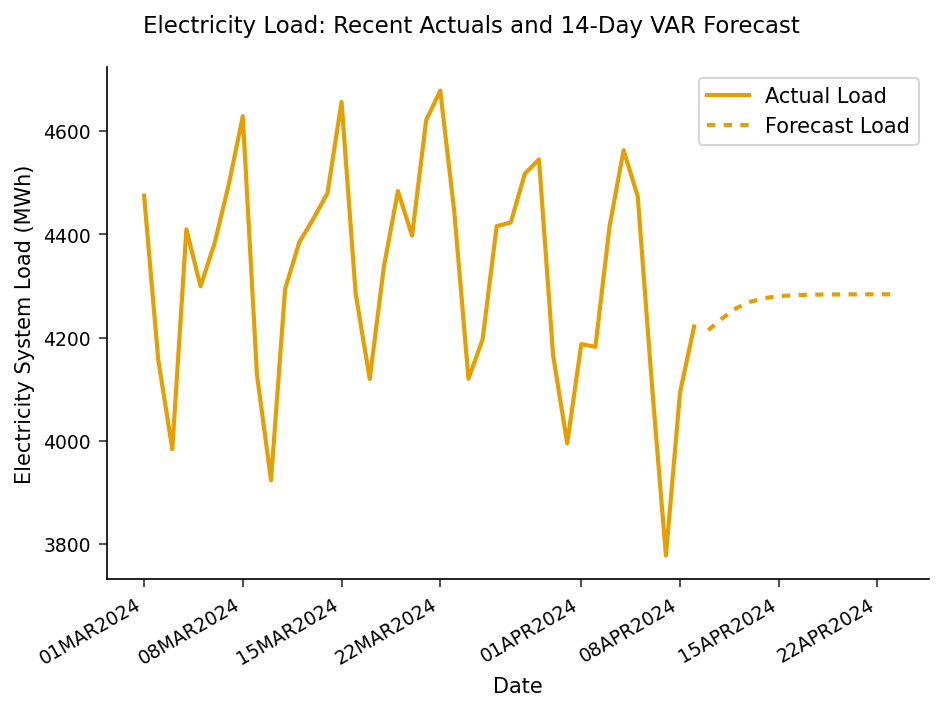

In [5]:
/* Recent actual load */
data recent_load;
    set utility;
    if day >= '01MAR2024'd;
    keep day load;
run;

/* Combine actuals and forecast for one plot */
data load_plot;
    set recent_load ss_horizon;
run;

proc sgplot data=load_plot;
    series x=day y=load    / lineattrs=(thickness=2)
          legendlabel='Actual Load';
    series x=day y=load_fc / lineattrs=(thickness=2 pattern=shortdash)
          legendlabel='Forecast Load';
    xaxis label='Date';
    yaxis label='Electricity System Load (MWh)';
    title 'Electricity Load: Recent Actuals and 14-Day VAR Forecast';
run;

## Interpreting the results

The value of the joint VAR is in **Step 3's coefficient matrix**: it estimates load and gas in one system, so the off-diagonal terms quantify how yesterday's value of one series helps predict today's value of the other. Here the model cleanly recovers load's own first-order persistence (0.59, highly significant) and finds a marginal load→gas spillover (0.087, \(p\approx0.07\)); the weaker gas→load feedback is not resolvable at 100 noisy observations. That honest result is itself informative for a utility: load history carries some signal for gas send-out, but a longer record would be needed before leaning on the reverse linkage operationally.

The **14-day forecasts (Steps 5–6)** converge smoothly from the last observed day toward each series' long-run mean — load to about **4284 MWh** and gas to about **1873 thousand therms** — which is the expected behavior of a stable, mean-reverting VAR once it projects beyond the reach of the most recent shocks. (Because the weekly weekday/weekend rhythm was injected as a deterministic effect in the data but not entered as a regressor in this model, the point forecasts smooth through it rather than reproducing the saw-tooth; adding day-of-week dummies via the VARMAX exogenous-input syntax would carry that pattern into the horizon.) For a utility, this joint view supports coordinated decisions — gas procurement and nominations on the fuel side, unit commitment and reserve planning on the electric side — from a single internally consistent model rather than two forecasts that may silently disagree.

**Caveats and next steps:** the synthetic series is intentionally simple (one weekly cycle, Gaussian shocks, no temperature regressor). In production you would add day-of-week and weather inputs as exogenous regressors, lengthen the history so weak cross-series feedback can be estimated precisely, validate stationarity, and back-test forecast accuracy by holding out recent days before trusting the horizon.